# Exploratory Data Analysis

Explores trip patterns, revenue trends, payment behavior, company performance, and seasonal effects. Also engineers new features and saves the cleaned dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('chicago_taxi_2024_cleaned.csv')

In [13]:
print(f"Total trips: {len(df):,}")
print(f"Total revenue: ${df['Trip Total'].sum():,.0f}")
print(f"Date range: {df['Trip Start Timestamp'].min()} → {df['Trip Start Timestamp'].max()}")

Total trips: 6,346,900
Total revenue: $180,638,977
Date range: 2024-01-01 00:15:00 → 2024-12-31 23:45:00


In [14]:
df[["Trip Miles", "Trip Minutes", "Fare", "Trip Total", "Speed MPH"]].describe().round(2)

,Trip Miles,Trip Minutes,Fare,Trip Total,Speed MPH
count,6346900.00,6346900.00,6346900.00,6346900.00,6346900.00
mean,6.93,21.61,23.06,28.46,18.08
std,7.75,27.42,19.10,24.47,163.45
min,0.00,0.02,0.01,0.01,0.00
25%,1.08,8.30,8.75,10.64,8.37
50%,3.49,16.22,16.75,19.82,13.90
75%,12.18,29.47,35.00,44.40,24.38
max,3397.80,1439.65,999.00,999.00,141033.50


In [16]:
df["Payment Type"].value_counts()

Payment Type
Credit Card    2542409
Cash           1747276
Mobile         1033828
Prcard          751689
Unknown         256635
No Charge        12125
Dispute           2934
Prepaid              4
Name: count, dtype: int64

In [17]:
df.groupby("Payment Type")[["Fare", "Tips"]].mean().round(2)

,Fare,Tips
Payment Type,,
Cash,18.72,0.00
Credit Card,27.83,6.15
Dispute,24.91,0.00
Mobile,17.08,3.14
No Charge,19.68,0.01
Prcard,24.86,0.17
Prepaid,3.50,0.00
Unknown,24.32,0.00


In [18]:
print(f"Trips with tip: {df['Is Tipped'].sum():,} ({df['Is Tipped'].mean()*100:.1f}%)")
df.groupby("Payment Type")["Is Tipped"].mean().round(3) * 100

Trips with tip: 3,280,826 (51.7%)


Payment Type
Cash            0.0
Credit Card    93.2
Dispute         0.0
Mobile         84.5
No Charge       0.1
Prcard          4.8
Prepaid         0.0
Unknown         0.2
Name: Is Tipped, dtype: float64

In [19]:
df.groupby("Trip Start Hour")["Trip ID"].count().sort_values(ascending=False).head(5)

Trip Start Hour
17    454171
16    443194
15    435330
14    425234
18    421311
Name: Trip ID, dtype: int64

In [20]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
df.groupby("Day of Week")["Trip ID"].count().reindex(day_order)

Day of Week
Monday        923991
Tuesday       993099
Wednesday    1014001
Thursday     1040455
Friday        970731
Saturday      718232
Sunday        686391
Name: Trip ID, dtype: int64

In [21]:
df["Company"].value_counts().head(10)

Company
Flash Cab                       1364484
Taxi Affiliation Services       1033450
Taxicab Insurance Agency Llc     717920
Sun Taxi                         714762
City Service                     604058
Chicago Independents             378759
5 Star Taxi                      296784
Blue Ribbon Taxi Association     243594
Globe Taxi                       227314
Medallion Leasin                 181524
Name: count, dtype: int64

In [22]:
df.groupby("Trip Start Month")["Trip ID"].count()

Trip Start Month
2024-01    415454
2024-02    430122
2024-03    510819
2024-04    532729
2024-05    605257
2024-06    595168
2024-07    535389
2024-08    553803
2024-09    553021
2024-10    588144
2024-11    531076
2024-12    495918
Name: Trip ID, dtype: int64

In [23]:
df["Pickup Community Area"].value_counts().head(10)

Pickup Community Area
76    1373101
8     1342288
32    1017253
28     592728
33     221438
56     217808
6      200295
7      128020
3       97331
77      75238
Name: count, dtype: Int64

In [24]:
print(f"Fare > $200: {(df['Fare'] > 200).sum():,}")
print(f"Trip Miles > 50: {(df['Trip Miles'] > 50).sum():,}")
print(f"Speed MPH > 100: {(df['Speed MPH'] > 100).sum():,}")

Fare > $200: 2,084
Trip Miles > 50: 3,468
Speed MPH > 100: 2,846


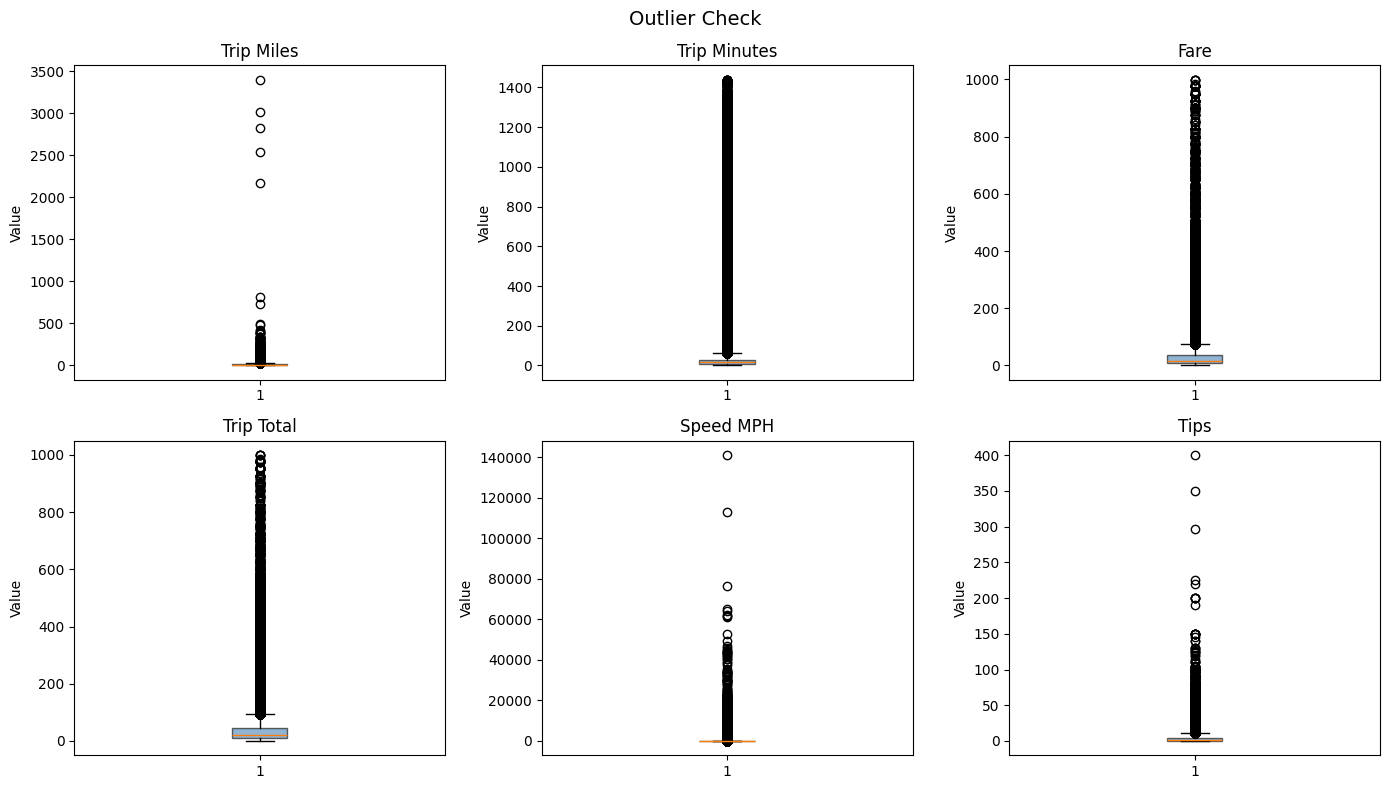

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Outlier Check", fontsize=14)

cols = ["Trip Miles", "Trip Minutes", "Fare", "Trip Total", "Speed MPH", "Tips"]

for ax, col in zip(axes.flatten(), cols):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col)
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

In [26]:
for col in ["Trip Miles", "Trip Minutes", "Fare", "Trip Total", "Speed MPH"]:
    print(f"{col}: 95th={df[col].quantile(0.95):.1f}  99th={df[col].quantile(0.99):.1f}  max={df[col].max():.1f}")

Trip Miles: 95th=18.4  99th=27.1  max=3397.8
Trip Minutes: 95th=55.0  99th=77.0  max=1439.7
Fare: 95th=52.0  99th=75.0  max=999.0
Trip Total: 95th=68.5  99th=100.0  max=999.0
Speed MPH: 95th=40.9  99th=51.0  max=141033.5


In [27]:
df = df[df["Trip Miles"] <= 60]
df = df[df["Trip Minutes"] <= 180]
df = df[df["Fare"] <= 200]
df = df[df["Trip Total"] <= 250]
df = df[df["Speed MPH"] <= 80]
df = df[df["Tips"] <= 100]

print(f"Rows remaining: {len(df):,}")
print(f"Rows dropped: {6_346_900 - len(df):,}")

Rows remaining: 6,334,213
Rows dropped: 12,687


In [28]:
# Season
def get_season(month):
    if month in [12, 1, 2]: return "Winter"
    elif month in [3, 4, 5]: return "Spring"
    elif month in [6, 7, 8]: return "Summer"
    else: return "Fall"

df["Season"] = df["Trip Start Timestamp"].dt.month.map(get_season)

In [29]:
# Time of day buckets
def get_time_of_day(hour):
    if 5 <= hour < 12: return "Morning"
    elif 12 <= hour < 17: return "Afternoon"
    elif 17 <= hour < 21: return "Evening"
    else: return "Night"

df["Time of Day"] = df["Trip Start Hour"].map(get_time_of_day)

In [30]:
# Is weekend
df["Is Weekend"] = df["Day of Week"].isin(["Saturday", "Sunday"]).astype(int)

In [31]:
# Fare per mile (efficiency metric)
df["Fare Per Mile"] = (df["Fare"] / df["Trip Miles"].replace(0, np.nan)).round(2)
df["Fare Per Mile"] = df["Fare Per Mile"].where(df["Fare Per Mile"] <= 50, np.nan)  # cap outliers

In [32]:
# Tip percentage
df["Tip Pct"] = ((df["Tips"] / df["Fare"].replace(0, np.nan)) * 100).round(2)
df["Tip Pct"] = df["Tip Pct"].where(df["Tip Pct"] <= 100, np.nan)  # cap at 100%

In [33]:
# Trip type based on distance
def classify_trip(miles):
    if miles < 2: return "Short"
    elif miles < 8: return "Medium"
    else: return "Long"

df["Trip Type"] = df["Trip Miles"].map(classify_trip)

In [41]:
# Seasonal breakdown
df.groupby("Season")[["Trip Miles", "Trip Minutes", "Fare", "Tip Pct"]].mean().round(2)

,Trip Miles,Trip Minutes,Fare,Tip Pct
Season,,,,
Fall,7.15,21.67,23.49,13.26
Spring,6.89,21.48,22.97,13.47
Summer,6.88,21.51,23.10,13.43
Winter,6.58,19.03,21.82,12.92


In [35]:
# Time of day patterns
df.groupby("Time of Day")[["Trip ID"]].count().rename(columns={"Trip ID": "Trip Count"})

,Trip Count
Time of Day,
Afternoon,2119420
Evening,1530454
Morning,1834363
Night,849976


In [36]:
# Weekend vs weekday
df.groupby("Is Weekend")[["Fare", "Trip Miles", "Tip Pct", "Speed MPH"]].mean().round(2)

,Fare,Trip Miles,Tip Pct,Speed MPH
Is Weekend,,,,
0,22.48,6.74,13.47,16.49
1,24.36,7.43,12.66,18.43


In [37]:
# Trip type distribution
df["Trip Type"].value_counts()

Trip Type
Short     2513026
Long      2386584
Medium    1434603
Name: count, dtype: int64

In [38]:
# Fare per mile by trip type — are short trips more expensive per mile?
df.groupby("Trip Type")[["Fare Per Mile", "Tip Pct", "Speed MPH"]].mean().round(2)

,Fare Per Mile,Tip Pct,Speed MPH
Trip Type,,,
Long,2.69,12.25,27.93
Medium,3.90,12.08,16.15
Short,9.01,14.98,6.90


In [39]:
# Monthly revenue trend
df.groupby("Trip Start Month")[["Fare", "Trip Total"]].sum().round(0)

,Fare,Trip Total
Trip Start Month,,
2024-01,9223065.0,11343936.0
2024-02,9442915.0,11557111.0
2024-03,11426475.0,14061506.0
2024-04,12067585.0,14904477.0
2024-05,14297096.0,17747820.0
2024-06,13755964.0,17163781.0
2024-07,12270400.0,15222152.0
2024-08,12794101.0,15856863.0
2024-09,13259444.0,16416737.0


In [40]:
# Peak hour by season — does rush hour shift?
df.groupby(["Season", "Trip Start Hour"])["Trip ID"].count().unstack("Season").fillna(0).astype(int)

Season,Fall,Spring,Summer,Winter
Trip Start Hour,,,,
0,23241,28209,31131,21358
1,13374,16527,19505,12288
2,7652,9524,11720,7067
3,6337,7480,8807,5674
4,9276,9461,10058,7026
5,16451,16418,17352,12120
6,31387,32122,32236,24513
7,61031,59567,56663,47642
8,87874,85128,82448,70711


In [42]:
# Average fare and tip by time of day
df.groupby("Time of Day")[["Fare", "Trip Miles", "Tip Pct", "Speed MPH"]].mean().round(2)

,Fare,Trip Miles,Tip Pct,Speed MPH
Time of Day,,,,
Afternoon,22.67,6.74,12.51,15.00
Evening,22.99,6.93,14.99,15.62
Morning,21.77,6.53,12.71,17.31
Night,25.74,7.98,13.42,23.19


In [43]:
# Company performance — trips, avg fare, avg tip pct
df.groupby("Company").agg(
    total_trips=("Trip ID", "count"),
    avg_fare=("Fare", "mean"),
    avg_tip_pct=("Tip Pct", "mean"),
    avg_miles=("Trip Miles", "mean")
).round(2).sort_values("total_trips", ascending=False).head(10)

,total_trips,avg_fare,avg_tip_pct,avg_miles
Company,,,,
Flash Cab,1361663,23.56,7.88,7.20
Taxi Affiliation Services,1031823,23.23,11.58,5.95
Taxicab Insurance Agency Llc,716860,23.50,16.93,7.30
Sun Taxi,713041,23.51,16.82,7.56
City Service,603309,22.36,15.68,7.11
Chicago Independents,378018,23.92,16.72,7.43
5 Star Taxi,295973,26.12,12.33,8.40
Blue Ribbon Taxi Association,242785,19.89,13.67,6.21
Globe Taxi,226976,21.89,15.03,6.95


In [44]:
# Revenue by season
df.groupby("Season")[["Fare", "Trip Total"]].agg(["sum", "mean"]).round(2)

Fare          Trip Total       
                sum   mean          sum   mean
Season                                        
Fall    39200926.23  23.49  48384204.38  28.99
Spring  37791156.15  22.97  46713802.49  28.39
Summer  38820464.30  23.10  48242795.48  28.70
Winter  29217793.85  21.82  35765282.40  26.71

In [45]:
# Weekend night vs weekday night — are late weekend rides more lucrative?
df.groupby(["Is Weekend", "Time of Day"])[["Fare", "Tip Pct", "Trip Miles"]].mean().round(2)

Fare  Tip Pct  Trip Miles
Is Weekend Time of Day                            
0          Afternoon    22.25    12.56        6.58
           Evening      22.53    15.25        6.73
           Morning      21.10    13.06        6.26
           Night        26.54    13.50        8.40
1          Afternoon    24.16    12.33        7.29
           Evening      24.50    14.12        7.58
           Morning      24.87    11.11        7.76
           Night        23.92    13.24        7.04

In [46]:
df.to_csv("chicago_taxi_2024_cleaned.csv", index=False)
print(f"Saved. Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Saved. Shape: (6334213, 34)
Columns: ['Trip ID', 'Taxi ID', 'Trip Start Timestamp', 'Trip End Timestamp', 'Trip Seconds', 'Trip Miles', 'Pickup Census Tract', 'Dropoff Census Tract', 'Pickup Community Area', 'Dropoff Community Area', 'Fare', 'Tips', 'Tolls', 'Extras', 'Trip Total', 'Payment Type', 'Company', 'Pickup Centroid Latitude', 'Pickup Centroid Longitude', 'Dropoff Centroid Latitude', 'Dropoff Centroid Longitude', 'Trip Minutes', 'Trip Start Hour', 'Trip Start Date', 'Trip Start Month', 'Day of Week', 'Is Tipped', 'Speed MPH', 'Season', 'Time of Day', 'Is Weekend', 'Fare Per Mile', 'Tip Pct', 'Trip Type']
